In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os
os.listdir()

In [ ]:
df=pd.read_csv("dataset/training.1600000.processed.noemoticon.csv",encoding="latin-1",header=None)

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.head()

In [ ]:
df.columns=['sentiment','id','date','query','user','text']

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df['sentiment'].value_counts()

In [ ]:
df['text'].head()

In [ ]:
df=df[['sentiment','text']].copy()

In [ ]:
df['sentiment']=df['sentiment'].replace('4','1')

In [ ]:
print(df['text'].iloc[0])

In [17]:
import re

def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove special characters and numbers, but keep spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text
    

In [18]:
df['clean_text'] = df['text'].apply(clean_text)

In [19]:
print(repr(df['clean_text'].iloc[3]))

'my whole body feels itchy and like its on fire'


In [20]:
df[['text','clean_text']].head()

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


In [21]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saund\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))

In [23]:
stop_words.remove('not')
stop_words.remove('nor')
stop_words.remove('no')

In [24]:
def remove_stopwords(text):
    words=text.split()
    words=[word for word in words if word not in stop_words]
    return ' '.join(words)

In [25]:
df['clean_text']=df['clean_text'].apply(remove_stopwords)

In [26]:
df[['text','clean_text']].head()

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats bummer shoulda got david carr third...
1,is upset that he can't update his Facebook by ...,upset cant update facebook texting might cry r...
2,@Kenichan I dived many times for the ball. Man...,dived many times ball managed save rest go bounds
3,my whole body feels itchy and like its on fire,whole body feels itchy like fire
4,"@nationwideclass no, it's not behaving at all....",no not behaving im mad cant see


In [27]:
from nltk.tokenize import word_tokenize

nltk.download('punkt')

df['tokens'] = df['clean_text'].apply(word_tokenize)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saund\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [28]:
print(word_tokenize(df['clean_text'].iloc[3]))

['whole', 'body', 'feels', 'itchy', 'like', 'fire']


In [29]:
df[['clean_text','tokens']].head()

,clean_text,tokens
0,awww thats bummer shoulda got david carr third...,"[awww, thats, bummer, shoulda, got, david, car..."
1,upset cant update facebook texting might cry r...,"[upset, cant, update, facebook, texting, might..."
2,dived many times ball managed save rest go bounds,"[dived, many, times, ball, managed, save, rest..."
3,whole body feels itchy like fire,"[whole, body, feels, itchy, like, fire]"
4,no not behaving im mad cant see,"[no, not, behaving, im, mad, cant, see]"


In [30]:
from nltk.stem import PorterStemmer
stemmer=PorterStemmer()

In [31]:
def stemming(tokens):
    return [stemmer.stem(word)for word in tokens]

In [32]:
df['stemmed']=df['tokens'].apply(stemming)

In [33]:
print(df['stemmed'].iloc[3])

['whole', 'bodi', 'feel', 'itchi', 'like', 'fire']


In [34]:
df[['tokens','stemmed']].head()

,tokens,stemmed
0,"[awww, thats, bummer, shoulda, got, david, car...","[awww, that, bummer, shoulda, got, david, carr..."
1,"[upset, cant, update, facebook, texting, might...","[upset, cant, updat, facebook, text, might, cr..."
2,"[dived, many, times, ball, managed, save, rest...","[dive, mani, time, ball, manag, save, rest, go..."
3,"[whole, body, feels, itchy, like, fire]","[whole, bodi, feel, itchi, like, fire]"
4,"[no, not, behaving, im, mad, cant, see]","[no, not, behav, im, mad, cant, see]"


In [35]:
df['stemmed_text'] = df['stemmed'].apply(lambda x: ' '.join(x))

In [36]:
print(df['stemmed_text'].iloc[0])

awww that bummer shoulda got david carr third day


In [37]:
X = df['stemmed_text']
y = df['sentiment']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [41]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [42]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.779328125


In [43]:
precision = precision_score(y_test, y_pred, average='weighted')

print("Precision:", precision)

Precision: 0.7796394061250013


In [44]:
recall = recall_score(y_test, y_pred,average='weighted')

print("Recall:", recall)

Recall: 0.779328125


In [45]:
f1 = f1_score(y_test, y_pred,average='weighted')

print("F1 Score:", f1)

F1 Score: 0.7792498437940031


In [46]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[121416  38078]
 [ 32537 127969]]


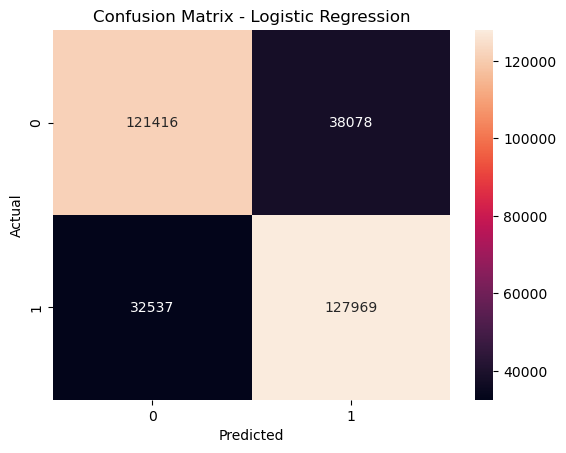

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.76      0.77    159494
           4       0.77      0.80      0.78    160506

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000



In [49]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

In [50]:
print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 0.7598


In [51]:
print("Precision:", precision_score(y_test, nb_pred,average='weighted'))

Precision: 0.7599087805262066


In [52]:
print("Recall:", recall_score(y_test, nb_pred,average='weighted'))

Recall: 0.7598


In [53]:
print("F1 Score:", f1_score(y_test, nb_pred,average='weighted'))

F1 Score: 0.759785442615134


In [54]:
cm_nb = confusion_matrix(y_test, nb_pred)

print(cm_nb)

[[122586  36908]
 [ 39956 120550]]


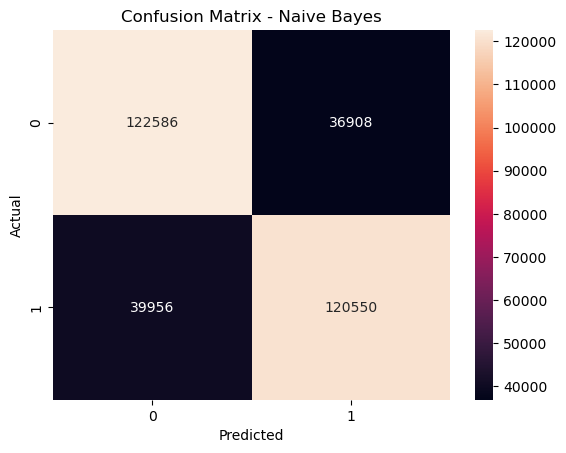

In [55]:
sns.heatmap(cm_nb, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [ ]:
print("Accuracy:", accuracy_score(y_test, svm_pred))

In [ ]:
print("Precision:", precision_score(y_test, svm_pred))

In [ ]:
print("Recall:", recall_score(y_test, svm_pred))

In [ ]:
print("F1 Score:", f1_score(y_test, svm_pred))

In [ ]:
print(classification_report(y_test, svm_pred))

In [ ]:
cm_svm = confusion_matrix(y_test, svm_pred)

print(cm_svm)

In [ ]:
sns.heatmap(cm_svm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

In [ ]:
rf_pred = rf_model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, rf_pred)

print(cm_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# DEEP LEARNING MODELS

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(df['text'])

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

# 1. Artificial Neural Network (ANN)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten

In [ ]:
model = Sequential()

model.add(Embedding(input_dim=10000, output_dim=128, input_length=100))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

In [ ]:
y_pred_prob = model.predict(X_test_pad)

In [ ]:
y_pred = (y_pred_prob > 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 2. Long Short-Term Memory (LSTM)

In [ ]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=100
    )
)

lstm_model.add(LSTM(128))

lstm_model.add(Dense(1, activation='sigmoid'))

In [ ]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

In [ ]:
y_pred_prob_lstm = lstm_model.predict(X_test_pad)

y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)

In [ ]:
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm = precision_score(y_test, y_pred_lstm)
recall_lstm = recall_score(y_test, y_pred_lstm)
f1_lstm = f1_score(y_test, y_pred_lstm)

print("Accuracy:", accuracy_lstm)
print("Precision:", precision_lstm)
print("Recall:", recall_lstm)
print("F1 Score:", f1_lstm)

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(cm_lstm)

# 3.Bidirectional Long Short-Term Memory (Bi-LSTM)

In [ ]:
from tensorflow.keras.layers import Bidirectional

In [ ]:
bilstm_model = Sequential()

bilstm_model.add(
    Embedding(
        input_dim=10000,
        output_dim=128,
        input_length=100
    )
)

bilstm_model.add(
    Bidirectional(LSTM(128))
)

bilstm_model.add(Dense(1, activation='sigmoid'))

In [ ]:
y_pred_prob_bilstm = bilstm_model.predict(X_test_pad)

y_pred_bilstm = (y_pred_prob_bilstm > 0.5).astype(int)

In [ ]:
accuracy_bilstm = accuracy_score(y_test, y_pred_bilstm)
precision_bilstm = precision_score(y_test, y_pred_bilstm)
recall_bilstm = recall_score(y_test, y_pred_bilstm)
f1_bilstm = f1_score(y_test, y_pred_bilstm)

print("Accuracy:", accuracy_bilstm)
print("Precision:", precision_bilstm)
print("Recall:", recall_bilstm)
print("F1 Score:", f1_bilstm)

cm_bilstm = confusion_matrix(y_test, y_pred_bilstm)
print(cm_bilstm)